# **Mall Customers Segmentation using K-Means Clustering**

### Problem Statement
You own the mall and want to understand the customers like who can be easily converge [Target Customers] so that the sense can be given to marketing team and plan the strategy accordingly.

In [1]:
# Import libraries
import os
os.environ["OMP_NUM_THREADS"] = "1" # the system can only use one thread

# to ignore all warnings
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# load the dataset
cs_df = pd.read_csv("Mall_Customers.csv")
cs_df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


## Exploratory Data Analysis(EDA)

In [3]:
cs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# numerical data
cs_df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
# categorical data
cs_df.describe(include=["object"])

,Gender
count,200
unique,2
top,Female
freq,112


In [6]:
# missing values
cs_df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
cs_df.shape

(200, 5)

In [8]:
cs_df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [9]:
cs_copy = cs_df.copy()

In [10]:
# which age group of customers has the highest spending score
bins = [0,20,30,40,50,60,100]
labels = ['0-20','21-30','31-40','41-50','51-60','60+']

cs_copy["Age_group"] = pd.cut(cs_df['Age'], bins=bins, labels=labels) #This divides the age into categories

cs_copy.groupby('Age_group')["Spending Score (1-100)"].mean().sort_values(ascending=False)

Age_group
21-30    67.222222
31-40    57.500000
0-20     44.647059
60+      44.176471
41-50    34.394737
51-60    32.521739
Name: Spending Score (1-100), dtype: float64

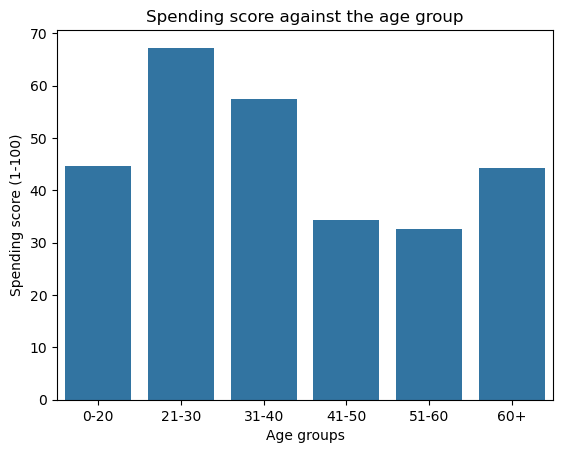

In [11]:
# plot spending score against age group
sns.barplot(data=cs_copy, x='Age_group', y='Spending Score (1-100)', ci=None)
plt.title("Spending score against the age group")
plt.xlabel('Age groups')
plt.ylabel('Spending score (1-100)')
plt.show()

In [12]:
# what is the average income of the customers
cs_copy['Annual Income (k$)'].mean()

np.float64(60.56)

In [13]:
# Which gender has the highest spending score (which gender spends more)
cs_copy.groupby('Gender')['Spending Score (1-100)'].sum()

Gender
Female    5771
Male      4269
Name: Spending Score (1-100), dtype: int64

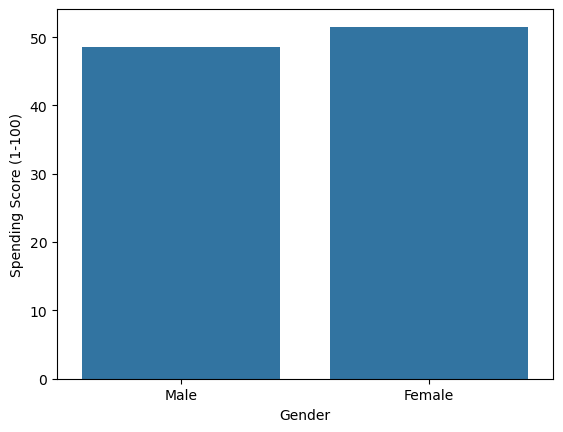

In [14]:
# visualise the gender and the spending score
sns.barplot(data=cs_df, x='Gender', y='Spending Score (1-100)', ci=None)
plt.show()

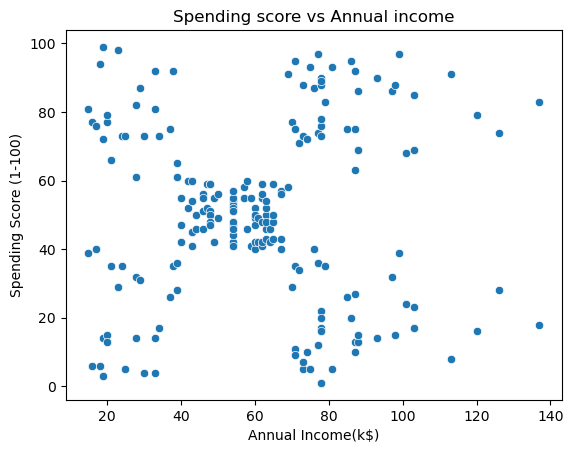

In [15]:
# do people with high annual income have a high spending score
sns.scatterplot(data=cs_df, x="Annual Income (k$)", y='Spending Score (1-100)')
plt.title("Spending score vs Annual income")
plt.xlabel('Annual Income(k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [16]:
# check for the relationship using correlation
cs_df['Annual Income (k$)'].corr(cs_df['Spending Score (1-100)'])

np.float64(0.009902848094037606)

## **Data Preprocessing**

In [17]:
cs_df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [18]:
# dropping invalid columns
cs_df.drop(['CustomerID','Gender'], axis=1, inplace=True)

In [19]:
cs_df.head(10)

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
5,22,17,76
6,35,18,6
7,23,18,94
8,64,19,3
9,30,19,72


## **Feature scaling**

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
# scaling the features
X = cs_df[['Age','Annual Income (k$)','Spending Score (1-100)']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

In [22]:
# view the scaled data
# scaled_features in the dataset
scaled_feature_df = pd.DataFrame(scaled_features, columns=X.columns)
scaled_feature_df.head(10)

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
5,-1.209269,-1.662660,1.001596
6,-0.276302,-1.624491,-1.715913
7,-1.137502,-1.624491,1.700384
8,1.804932,-1.586321,-1.832378
9,-0.635135,-1.586321,0.846310


## **Finding optimal number of clusters using the Elbow method**

In [23]:
from sklearn.cluster import KMeans

In [24]:
# using the elbow method to get clusters 
inertias = []
ks = range(1,11)

for k in ks:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_features)
    inertias.append(model.inertia_)

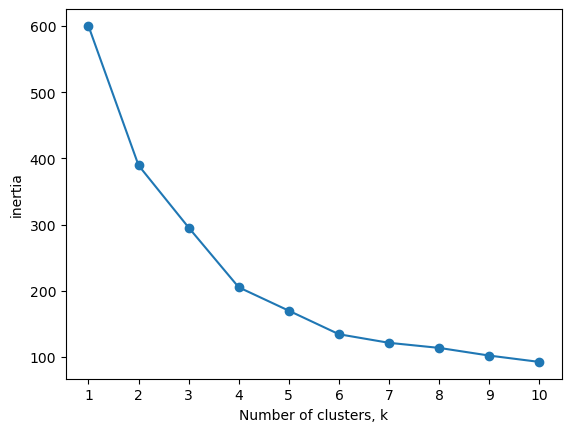

In [25]:
# visualize the clusters
plt.plot(ks,inertias,'-o')
plt.xlabel('Number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

### **Predicting the kmeans model (the cluseters are 4)**


In [26]:
kmeans = KMeans(n_clusters=4, random_state=42)
cs_df['Clusters'] = kmeans.fit_predict(scaled_features)

In [27]:
# obtaining the centroids
print(kmeans.cluster_centers_)

[[ 1.08616125 -0.49056525 -0.39717443]
 [-0.42880597  0.97484722  1.21608539]
 [-0.96249203 -0.78476346  0.39202966]
 [ 0.03720536  0.99011499 -1.18875705]]


In [28]:
# inverse transforming the centroids to observe them in their original form before scaling
original_centroids = scaler.inverse_transform(kmeans.cluster_centers_)
print(original_centroids)

[[53.98461538 47.70769231 39.96923077]
 [32.875      86.1        81.525     ]
 [25.43859649 40.         60.29824561]
 [39.36842105 86.5        19.57894737]]


Text(0.5, 1.0, 'Annual Income Vs Spending score')

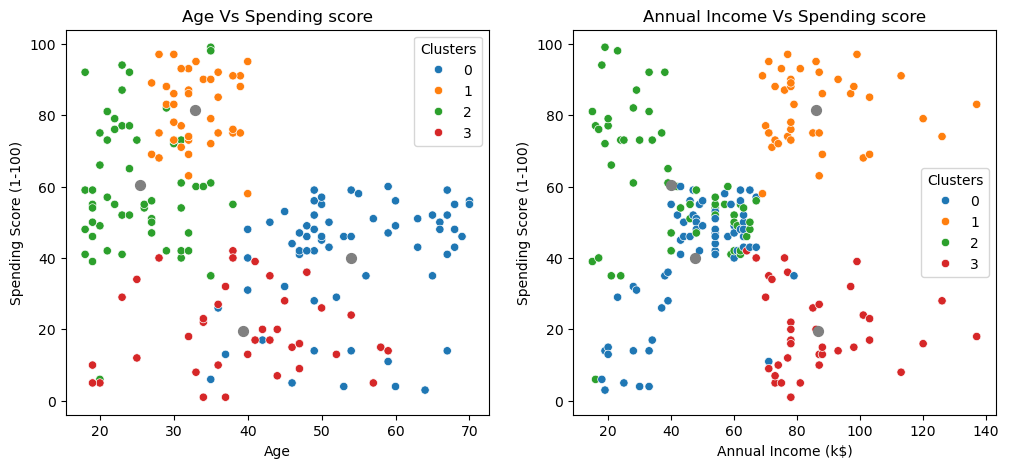

In [29]:
# plotting the clusters
fig,(ax1,ax2) = plt.subplots(1,2 , figsize=(12,5))
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='Clusters', data=cs_df, palette='tab10',ax=ax1)
sns.scatterplot(x='Annual Income (k$)', y= 'Spending Score (1-100)', hue='Clusters', data=cs_df, palette='tab10',ax=ax2)
ax1.scatter(original_centroids[:, 0], original_centroids[:, 2], s=50, c='grey', marker='o', label='Centroids')
ax2.scatter(original_centroids[:, 1], original_centroids[:, 2], s=50, c='grey', marker='o', label='Centroids')
ax1.set_title('Age Vs Spending score')
ax2.set_title('Annual Income Vs Spending score')

In [30]:
# Mean
cs_df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

Age                       38.85
Annual Income (k$)        60.56
Spending Score (1-100)    50.20
dtype: float64

In [31]:
analyze_clusters = cs_df.groupby('Clusters').mean()
print(analyze_clusters)

                Age  Annual Income (k$)  Spending Score (1-100)
Clusters                                                       
0         53.984615           47.707692               39.969231
1         32.875000           86.100000               81.525000
2         25.438596           40.000000               60.298246
3         39.368421           86.500000               19.578947


### **Analysis from the second model**
- cluster 0: customers that are older with income below average have a moderate spending score
- cluster 1: customers that are young adults with high average income with a high average spending score
- cluster 2: customers that are young adults with a low average income and a moderate average spending score
- cluster 3: customers that are slightly above average age with a high average income and a low average spending score

## **Improving the cluster model**

In [32]:
# dropping the age column
cs_df.drop(['Age','Clusters'], axis=1, inplace=True)

In [33]:
# show current dataframe
cs_df.head(10)

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
5,17,76
6,18,6
7,18,94
8,19,3
9,19,72


In [34]:
# using the elbow method to get clusters for the two columns
X_cluster = cs_df[['Annual Income (k$)', 'Spending Score (1-100)']]
inertias = []
ks = range(1,11)

for k in ks:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_cluster)
    inertias.append(model.inertia_)

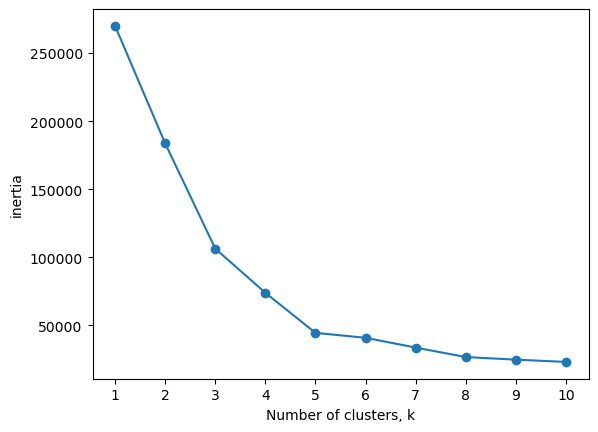

In [35]:
# visualize the clusters
plt.plot(ks,inertias,'-o')
plt.xlabel('Number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

In [36]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_cluster)
cs_df['Clusters'] = kmeans.predict(X_cluster)

In [37]:
# obtaining the centroids
print(kmeans.cluster_centers_)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [38]:
# the centroids for the two columns
centroids = kmeans.cluster_centers_

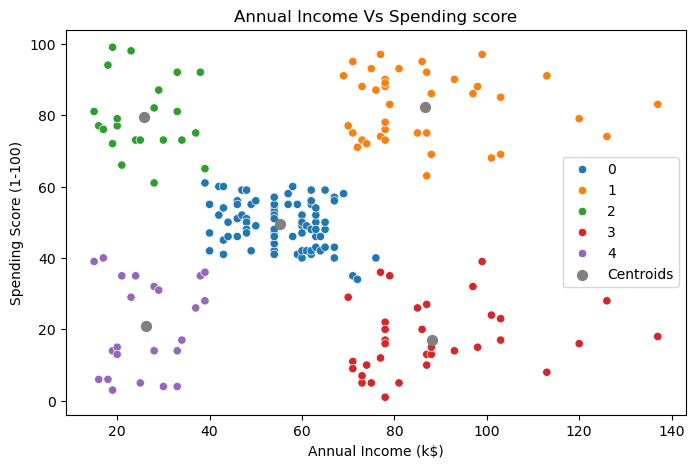

In [39]:
# plotting the clusters
plt.figure(figsize=(8,5))
sns.scatterplot(x='Annual Income (k$)', y= 'Spending Score (1-100)', hue='Clusters', data=cs_df, palette='tab10')
plt.scatter(centroids[:, 0], centroids[:, 1], s=50, c='grey', marker='o', label='Centroids')
plt.title('Annual Income Vs Spending score')
plt.legend()
plt.show()

In [40]:
# the Mean of both columns
cs_df[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

Annual Income (k$)        60.56
Spending Score (1-100)    50.20
dtype: float64

In [41]:
# Analysing the clusters
analyze_clusters = cs_df.groupby('Clusters').mean()
print(analyze_clusters)

          Annual Income (k$)  Spending Score (1-100)
Clusters                                            
0                  55.296296               49.518519
1                  86.538462               82.128205
2                  25.727273               79.363636
3                  88.200000               17.114286
4                  26.304348               20.913043


### **Analysis from the second model**
- cluster 0: Customers with an average annual income have a moderate spending score. 
- cluster 1: Customers with high annual income have a high spending score.
- cluster 2: Customers with the lowest annual income have a high spending score.
- cluster 3: Customers with the highest annual income have the lowest spending score.
- cluster 4: Customers with low annual income have a low spending score.

#### **Insights from the models predicted**
The second model provides clearer and more actionable customer segments than the first model because spending behavior is more directly related to income than age. Therefore, the 5-cluster model should be preferred for marketing decisions.

## **Overall overview and summary of the project**
The objective of this project was to segment mall customers into groups with similar characteristics and behaviours  using K-Means clustering. Exploratory Data Analysis (EDA) showed that younger customers generally have higher spending scores, while annual income alone had a weak relationship with spending behavior. After preprocessing and scaling the data, used the Elbow Method to determine the optimal number of clusters which gave us 4 clusters for the first model and 5 clusters for the last model. Customer segmentation revealed distinct groups that can help the marketing team create targeted promotional strategies and improve customer engagement.